In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


Задача 1. Верификация моментов процесса CIR

In [2]:
kappa = 2.0
theta = 1.0
sigma = 0.3
X0 = 1.5
T = 2.0
dt = 0.001
M = 1000  # Количество траекторий
N = int(T / dt)
t = np.linspace(0, T, N + 1)

# Симуляция CIR (схема Эйлера-Маруямы с усечением для положительности)
def simulate_cir(M, N, T, X0, kappa, theta, sigma):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    
    for i in range(N):
        dX = kappa * (theta - X[:, i]) * dt + sigma * np.sqrt(np.maximum(X[:, i], 0)) * dW[:, i]
        X[:, i + 1] = X[:, i] + dX
        # Усечение для избежания отрицательных значений (полная схема усечения)
        X[:, i + 1] = np.maximum(X[:, i + 1], 0)
    return t, X

t, X_paths = simulate_cir(M, N, T, X0, kappa, theta, sigma)

# Теоретические моменты в момент T
E_X_T = theta + (X0 - theta) * np.exp(-kappa * T)
Var_X_T = (sigma**2 / (2 * kappa)) * theta * (1 - np.exp(-kappa * T))**2 + \
          X0 * (sigma**2 / kappa) * np.exp(-kappa * T) * (1 - np.exp(-kappa * T))
E_X2_T = Var_X_T + E_X_T**2

# Выборочные моменты
sample_mean = np.mean(X_paths[:, -1])
sample_var = np.var(X_paths[:, -1])
sample_moment2 = np.mean(X_paths[:, -1]**2)

print(f"Задача 1: Верификация моментов CIR")
print(f"Теоретическое E[X(T)]: {E_X_T:.4f}, Выборочное: {sample_mean:.4f}")
print(f"Теоретическое E[X^2(T)]: {E_X2_T:.4f}, Выборочное: {sample_moment2:.4f}")
print(f"Теоретическая Var(X(T)): {Var_X_T:.4f}, Выборочная: {sample_var:.4f}")

Задача 1: Верификация моментов CIR
Теоретическое E[X(T)]: 1.0092, Выборочное: 1.0148
Теоретическое E[X^2(T)]: 1.0413, Выборочное: 1.0510
Теоретическая Var(X(T)): 0.0229, Выборочная: 0.0211


Задача 2. Свойства модели Блэка-Шоулза-Мертона

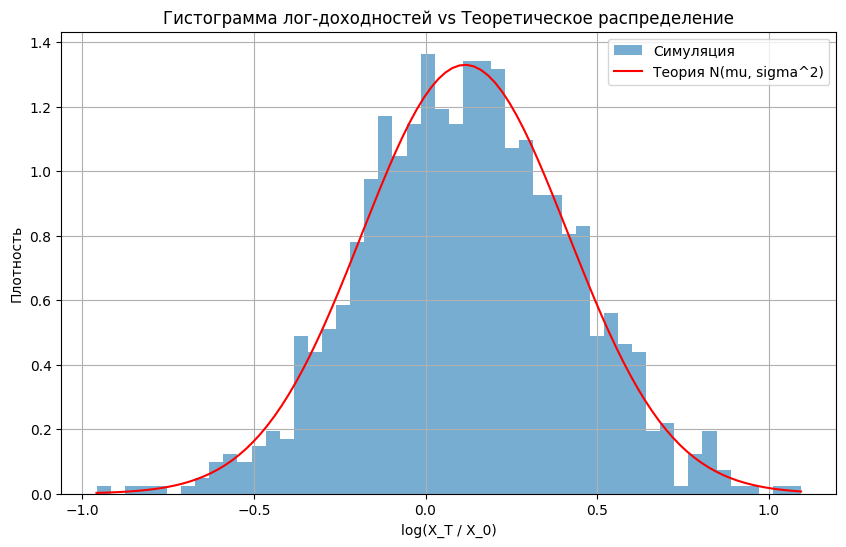

Задача 2: Теоретическое среднее лог-доходности: 0.1150, Выборочное: 0.1188
Теоретическая дисперсия лог-доходности: 0.0900, Выборочная: 0.0923


In [ ]:
theta1 = 0.16  # Процентная ставка
theta2 = 0.30  # Волатильность
X0 = 1.0
T = 1.0
dt = 0.001
N = int(T / dt)
M = 1000

# Симуляция BSM
def simulate_bsm(M, N, T, X0, mu, sigma):
    dt = T / N
    t = np.linspace(0, T, N + 1)
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    
    for i in range(N):
        dX = mu * X[:, i] * dt + sigma * X[:, i] * dW[:, i]
        X[:, i + 1] = X[:, i] + dX
    return t, X

t, X_paths_bsm = simulate_bsm(M, N, T, X0, theta1, theta2)

# Лог-доходности
log_returns = np.log(X_paths_bsm[:, -1] / X0)

# Теоретические параметры для лог-доходностей
mu_log = (theta1 - 0.5 * theta2**2) * T
sigma_log = theta2 * np.sqrt(T)

plt.figure(figsize=(10, 6))
plt.hist(log_returns, bins=50, density=True, alpha=0.6, label='Симуляция')
x = np.linspace(min(log_returns), max(log_returns), 100)
plt.plot(x, norm.pdf(x, mu_log, sigma_log), 'r-', label='Теория N(mu, sigma^2)')
plt.title('Гистограмма лог-доходностей vs Теоретическое распределение')
plt.xlabel('log(X_T / X_0)')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)
plt.show()

print(f"Задача 2: Теоретическое среднее лог-доходности: {mu_log:.4f}, Выборочное: {np.mean(log_returns):.4f}")
print(f"Теоретическая дисперсия лог-доходности: {sigma_log**2:.4f}, Выборочная: {np.var(log_returns):.4f}")

Задача 3. Модель стохастической волатильности (BSM + CIR)

Параметры:
Количество траекторий: M = 1000
Первый интервал: [0.2, 0.4]
Второй интервал: [0.6, 0.8]

Результаты:
Корреляция между ΔW1 и ΔW2: -0.002774
P-value: 0.930181

Теоретическая корреляция для непересекающихся интервалов: 0
Разница: 0.002774


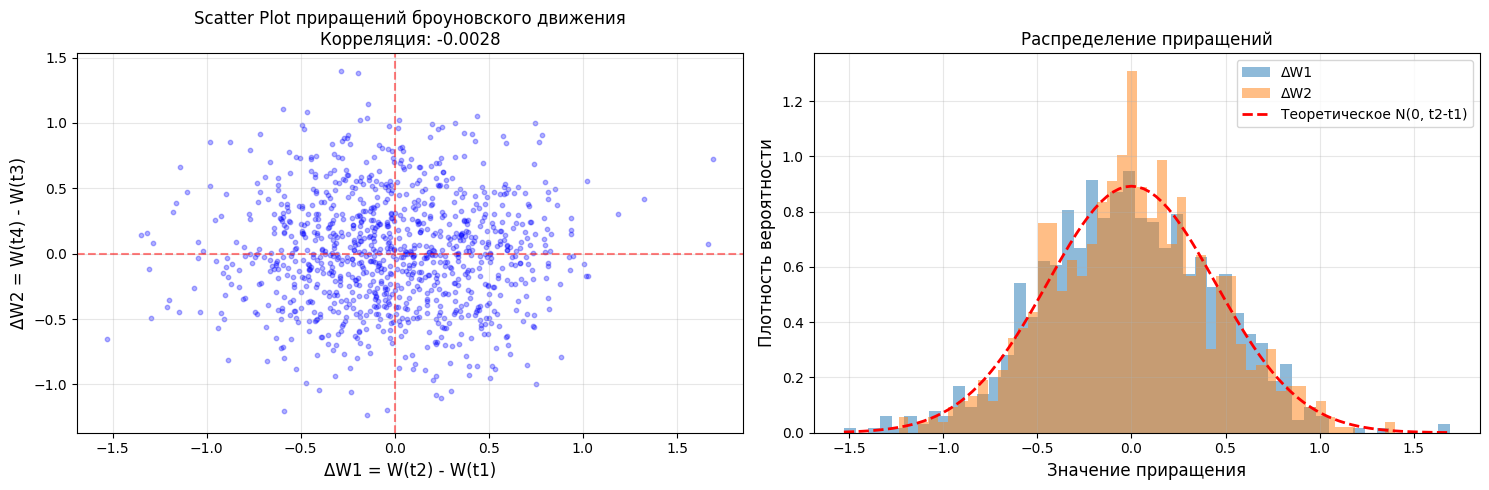

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

M = 1000  # Количество траекторий
T = 1.0   # Общее время
Nt = 1000 # Количество шагов по времени
dt = T / Nt
t = np.linspace(0, T, Nt + 1)

# Выбираем два непересекающихся интервала
t1, t2 = 0.2, 0.4  # Первый интервал
t3, t4 = 0.6, 0.8  # Второй интервал (не пересекается с первым)

# Индексы для временных интервалов
idx_t1 = int(t1 / dt)
idx_t2 = int(t2 / dt)
idx_t3 = int(t3 / dt)
idx_t4 = int(t4 / dt)

# Массивы для хранения приращений
delta_W1 = np.zeros(M)
delta_W2 = np.zeros(M)

# Генерация M траекторий броуновского движения
np.random.seed(42)  

for i in range(M):
    # Генерируем броуновское движение
    dW = np.random.normal(0, np.sqrt(dt), Nt)
    W = np.cumsum(dW)
    W = np.insert(W, 0, 0)  # W(0) = 0
    
    delta_W1[i] = W[idx_t2] - W[idx_t1]
    delta_W2[i] = W[idx_t4] - W[idx_t3]

# Вычисляем корреляцию между приращениями
correlation, p_value = stats.pearsonr(delta_W1, delta_W2)

print(f"Параметры:")
print(f"Количество траекторий: M = {M}")
print(f"Первый интервал: [{t1}, {t2}]")
print(f"Второй интервал: [{t3}, {t4}]")
print(f"\nРезультаты:")
print(f"Корреляция между ΔW1 и ΔW2: {correlation:.6f}")
print(f"P-value: {p_value:.6f}")
print(f"\nТеоретическая корреляция для непересекающихся интервалов: 0")
print(f"Разница: {abs(correlation):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(delta_W1, delta_W2, alpha=0.3, s=10, color='blue')
axes[0].set_xlabel('ΔW1 = W(t2) - W(t1)', fontsize=12)
axes[0].set_ylabel('ΔW2 = W(t4) - W(t3)', fontsize=12)
axes[0].set_title(f'Scatter Plot приращений броуновского движения\nКорреляция: {correlation:.4f}', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Гистограммы распределений
axes[1].hist(delta_W1, bins=50, alpha=0.5, label='ΔW1', density=True)
axes[1].hist(delta_W2, bins=50, alpha=0.5, label='ΔW2', density=True)

# Теоретическое нормальное распределение
x = np.linspace(min(min(delta_W1), min(delta_W2)), 
                max(max(delta_W1), max(delta_W2)), 100)
theoretical_std = np.sqrt(t2 - t1)  # Дисперсия приращения броуновского движения
axes[1].plot(x, stats.norm.pdf(x, 0, theoretical_std), 'r--', 
             label='Теоретическое N(0, t2-t1)', linewidth=2)
axes[1].set_xlabel('Значение приращения', fontsize=12)
axes[1].set_ylabel('Плотность вероятности', fontsize=12)
axes[1].set_title('Распределение приращений', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Задача 4. Смена режима для траектории (Regime Switching)

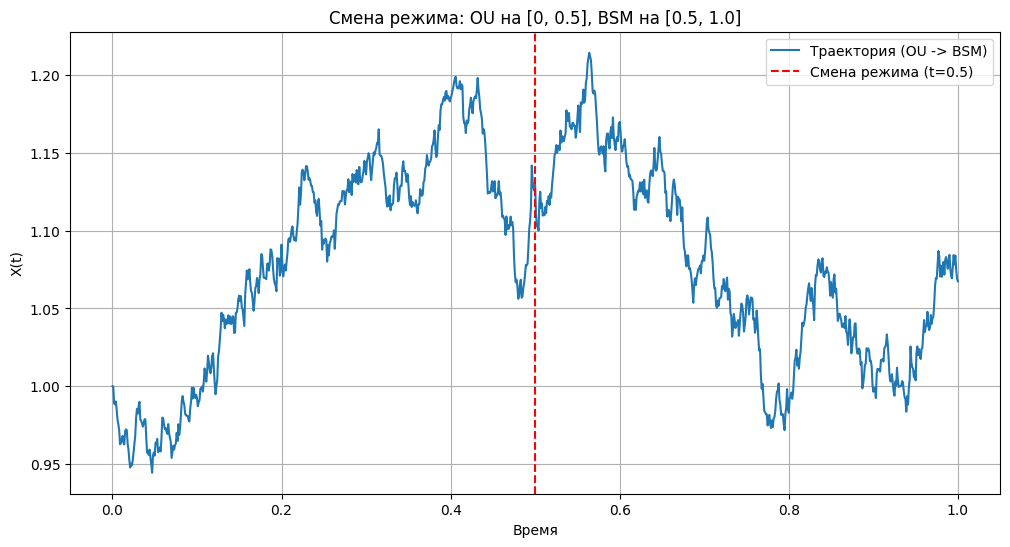

Результаты сохранены в 'regime_switch_trajectory.csv'


In [ ]:
T1 = 0.5
T2 = 1.0
dt = 0.001
N1 = int(T1 / dt)
N2 = int((T2 - T1) / dt)
N_total = N1 + N2
t1 = np.linspace(0, T1, N1 + 1)
t2 = np.linspace(T1, T2, N2 + 1)
t = np.concatenate((t1, t2[1:]))

# Параметры OU
kappa = 1.0
theta = 1.2
sigma_ou = 0.2
X0_ou = 1.0

# Симуляция OU
X_ou = np.zeros(N1 + 1)
X_ou[0] = X0_ou
dW_ou = np.random.normal(0, np.sqrt(dt), N1)
for i in range(N1):
    dX = kappa * (theta - X_ou[i]) * dt + sigma_ou * dW_ou[i]
    X_ou[i + 1] = X_ou[i] + dX

# Параметры BSM для второй части
mu_bsm = 0.05
sigma_bsm = 0.2
X0_bsm = X_ou[-1] # Начальное состояние для BSM - конец OU

# Симуляция BSM
X_bsm = np.zeros(N2 + 1)
X_bsm[0] = X0_bsm
dW_bsm = np.random.normal(0, np.sqrt(dt), N2)
for i in range(N2):
    dX = mu_bsm * X_bsm[i] * dt + sigma_bsm * X_bsm[i] * dW_bsm[i]
    X_bsm[i + 1] = X_bsm[i] + dX

# Объединение траекторий
X_total = np.concatenate((X_ou, X_bsm[1:]))

plt.figure(figsize=(12, 6))
plt.plot(t, X_total, label='Траектория (OU -> BSM)')
plt.axvline(x=T1, color='r', linestyle='--', label='Смена режима (t=0.5)')
plt.title('Смена режима: OU на [0, 0.5], BSM на [0.5, 1.0]')
plt.xlabel('Время')
plt.ylabel('X(t)')
plt.legend()
plt.grid(True)
plt.show()

# Сохранение в CSV
data_switch = np.column_stack((t, X_total))
np.savetxt('regime_switch_trajectory.csv', data_switch, delimiter=',', header='t,X', comments='')
print("Результаты сохранены в 'regime_switch_trajectory.csv'")

Задача 5. Сравнение моделей с возвратом к среднему

Задача 5: Статистика в момент T
OU: Mean=0.9999, Var=0.0215, P(X>2)=0.0000
CIR: Mean=1.0140, Var=0.0234, P(X>2)=0.0000
Mod CIR: Mean=1.0197, Var=0.0272, P(X>2)=0.0000
Ait-Sahalia: Mean=0.5292, Var=0.0019, P(X>2)=0.0000
Jacobi: Mean=0.5010, Var=0.0058, P(X>2)=0.0000


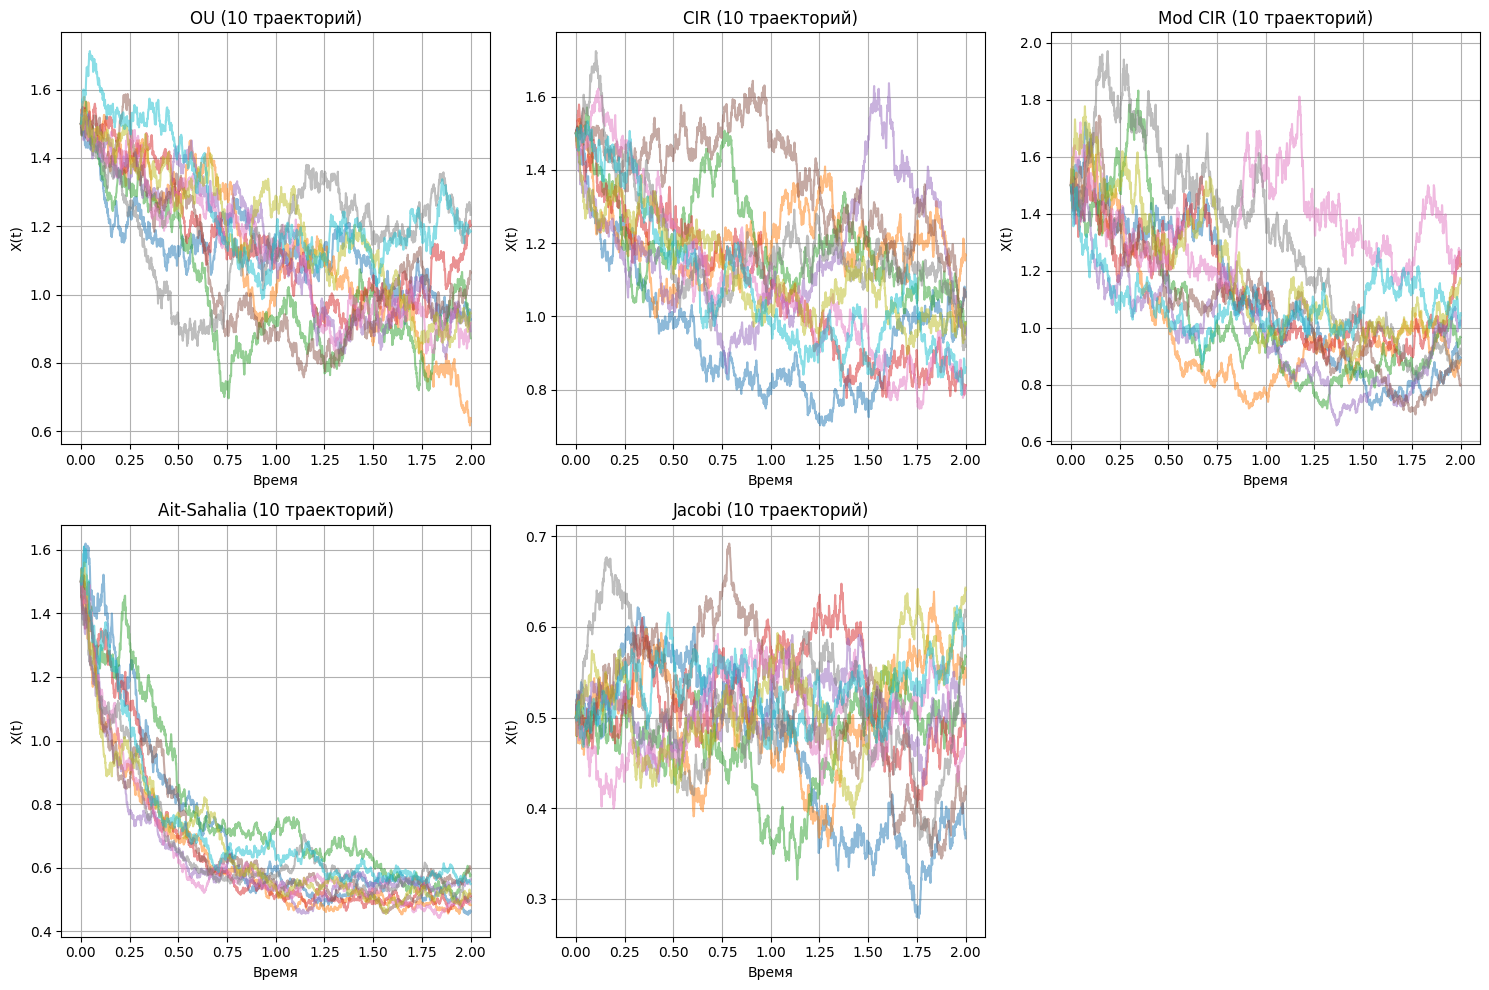

In [ ]:
kappa = 2.0
theta = 1.0
sigma = 0.3
X0 = 1.5
T = 2.0
dt = 0.001
N = int(T / dt)
M = 500
t = np.linspace(0, T, N + 1)

def simulate_ou(M, N, T, X0, kappa, theta, sigma):
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    for i in range(N):
        X[:, i + 1] = X[:, i] + kappa * (theta - X[:, i]) * dt + sigma * dW[:, i]
    return X

def simulate_cir(M, N, T, X0, kappa, theta, sigma):
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    for i in range(N):
        X[:, i + 1] = X[:, i] + kappa * (theta - X[:, i]) * dt + sigma * np.sqrt(np.maximum(X[:, i], 0)) * dW[:, i]
        X[:, i + 1] = np.maximum(X[:, i + 1], 0)
    return X

def simulate_mod_cir(M, N, T, X0, kappa, theta, sigma):
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    for i in range(N):
        X[:, i + 1] = X[:, i] + kappa * (theta - X[:, i]) * dt + sigma * np.abs(X[:, i])**1.5 * dW[:, i]
    return X

def simulate_ait_sahalia(M, N, T, X0, alpha_m1, alpha_0, alpha_1, alpha_2, rho, sigma):
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    for i in range(N):
        drift = (alpha_m1 / X[:, i] + alpha_0 + alpha_1 * X[:, i] + alpha_2 * X[:, i]**2) * dt
        diffusion = sigma * np.abs(X[:, i])**rho * dW[:, i]
        X[:, i + 1] = X[:, i] + drift + diffusion
        X[:, i + 1] = np.maximum(X[:, i + 1], 0) # Ограничение снизу для стабильности
    return X

def simulate_jacobi(M, N, T, X0, kappa, theta, sigma):
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    for i in range(N):
        drift = kappa * (theta - X[:, i]) * dt
        diffusion = sigma * np.sqrt(X[:, i] * (1 - X[:, i])) * dW[:, i]
        X[:, i + 1] = X[:, i] + drift + diffusion
        X[:, i + 1] = np.clip(X[:, i + 1], 0, 1) # Ограничение [0, 1]
    return X

# Симуляция
X_ou = simulate_ou(M, N, T, X0, kappa, theta, sigma)
X_cir = simulate_cir(M, N, T, X0, kappa, theta, sigma)
X_mod_cir = simulate_mod_cir(M, N, T, X0, kappa, theta, sigma)
X_ait = simulate_ait_sahalia(M, N, T, X0, 0.5, 0.1, -2, 0, 1.5, sigma)
X_jac = simulate_jacobi(M, N, T, 0.5, kappa, 0.5, sigma) 

# Анализ
models = {'OU': X_ou, 'CIR': X_cir, 'Mod CIR': X_mod_cir, 'Ait-Sahalia': X_ait, 'Jacobi': X_jac}
print("Задача 5: Статистика в момент T")
for name, X in models.items():
    mean_T = np.mean(X[:, -1])
    var_T = np.var(X[:, -1])
    prob_threshold = np.mean(X[:, -1] > 2.0)
    print(f"{name}: Mean={mean_T:.4f}, Var={var_T:.4f}, P(X>2)={prob_threshold:.4f}")

plt.figure(figsize=(15, 10))
for i, (name, X) in enumerate(models.items()):
    plt.subplot(2, 3, i + 1)
    for j in range(10):
        plt.plot(t, X[j, :], alpha=0.5)
    plt.title(f'{name} (10 траекторий)')
    plt.xlabel('Время')
    plt.ylabel('X(t)')
    plt.grid(True)
plt.tight_layout()
plt.show()

Задача 6. 2D Процесс

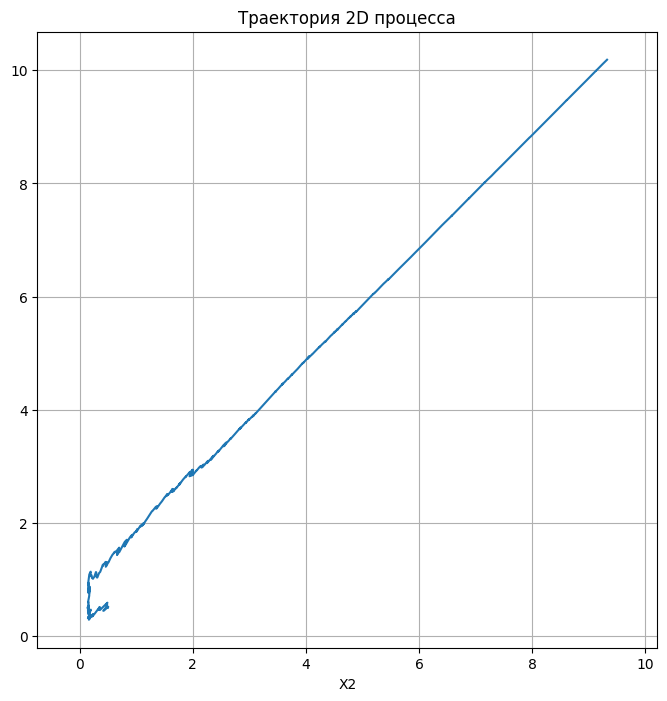

In [ ]:
T = 10.0
dt = 0.01
N = int(T / dt)
t = np.linspace(0, T, N + 1)

# Начальное условие
X1 = np.zeros(N + 1)
X2 = np.zeros(N + 1)
X1[0] = 0.5
X2[0] = 0.5

# Симуляция
dW = np.random.normal(0, np.sqrt(dt), N)
for i in range(N):
    r2 = X1[i]**2 + X2[i]**2
    # Дрейф
    if r2 > 1:
        mu1 = 1.0
        mu2 = 1.0
    else:
        mu1 = -X1[i]
        mu2 = X2[i]

    sigma1 = X1[i] / (1 + r2)
    sigma2 = X2[i] / (1 + r2)
    
    X1[i + 1] = X1[i] + mu1 * dt + sigma1 * dW[i]
    X2[i + 1] = X2[i] + mu2 * dt + sigma2 * dW[i]

plt.figure(figsize=(8, 8))
plt.plot(X1, X2)
plt.title('Траектория 2D процесса')
plt.xlabel('X1')
plt.xlabel('X2')
plt.grid(True)
plt.axis('equal')
plt.show()